In [1]:
import IPython
import os
notebook_path = "/".join(
        IPython.extract_module_locals()[1]["__vsc_ipynb_file__"].split("/")
    )
notebook_dir = os.path.dirname(os.path.abspath(notebook_path))
os.chdir(notebook_dir)
os.chdir('../../../')
!pwd

/Users/vipin/BHT - Data Science/CalgoLab/BGR


In [2]:
import sqlite3
import pandas as pd
import ast
import re
import os

db_path = '../data/BGR/sqlite/database_soilnet-study_27-01-26.db'
table = 'predictions'

if os.path.exists(db_path):
    print(f"Database found at {db_path}")
else:
    raise FileNotFoundError(f"Database not found at {db_path}")

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql(f"SELECT * FROM {table}", conn, index_col='id')
    
    df['time_stamp'] = pd.to_datetime(df['time_stamp']) # Convert timestamp to datetime
    
    df['skipped'] = df['skipped'].astype(bool) # Convert skipped to integer
    
    df["image_name"] = df["image_path"].apply(lambda x: os.path.basename(x)) # Extract image name from path
    
    df['depths'] = df['depths'].apply(lambda x: x.replace('[', '').replace(']', '').split(',') if pd.notnull(x) else []) # Split depths into list
    df['depths'] = df['depths'].apply(lambda lst: [float(i) if i != '' else None for i in lst]) # Convert depths to float
    df['depths'] = df['depths'].apply(lambda lst: [d for d in lst if d is not None]) # Remove None values
    
    df['symbols'] = df['symbols'].apply(lambda x: x.replace('[', '').replace(']', '').split(',') if pd.notnull(x) else []) # Split symbols into list
    df['symbols'] = df['symbols'].apply(lambda lst: [s.strip().strip("'").strip('"')for s in lst]) # Clean symbols
    
    df['ml_assisted'] = df['ml_assisted'].astype(bool) # Convert ml_assisted to integer

    # Parse ml_depths safely: accept lists or stringified lists
    df['ml_depths'] = df['ml_depths'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and isinstance(x, str) else (x if pd.notnull(x) else []))

    def _parse_ml_symbols(x):
        if pd.isnull(x):
            return []
        if isinstance(x, list):
            return x
        try:
            return ast.literal_eval(x)
        except Exception:
            parts = re.findall(r'\[([^]]+)\]', str(x))
            out = []
            for p in parts:
                items = [s.strip().strip("'\"") for s in p.split(',') if s.strip()]
                out.append(items)
            return out

    df['ml_symbols'] = df['ml_symbols'].apply(_parse_ml_symbols)
    
    df = df[['time_stamp', 'image_idx', 'image_name', 'anonId', 'skipped', 'depths', 'symbols', 'ml_assisted', 'ml_depths', 'ml_symbols']] # Reorder columns
    
    df = df[df['anonId'] != 'demo_user'] # Remove demo_user entries

df_all = df
df_ml_assisted = df[df['ml_assisted'] == True]
df_non_assisted = df[df['ml_assisted'] == False]
print(f"ML Assisted entries: {len(df_ml_assisted)}, Skipped ratio: {df_ml_assisted['skipped'].mean():.2%}")
display(df_ml_assisted.head())
print(f"Non-ML Assisted entries: {len(df_non_assisted)}, Skipped ratio: {df_non_assisted['skipped'].mean():.2%}")
display(df_non_assisted.head())

Database found at ../data/BGR/sqlite/database_soilnet-study_27-01-26.db
ML Assisted entries: 325, Skipped ratio: 73.85%


,time_stamp,image_idx,image_name,anonId,skipped,depths,symbols,ml_assisted,ml_depths,ml_symbols
id,,,,,,,,,,
393,2026-01-16 21:49:51.353703,336,NI_0970_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,"[0.08874928301030992, 0.47325979687950875, 0.7...","[Ah, Bv, Bv-Cv, Cv]",True,"[0.2853715419769287, 0.556149423122406, 0.8318...","[[Ap, Sw-Ap, Ah, Aep, Axp], [Ah-Bv, Ael-Bv, Al..."
394,2026-01-16 22:01:13.331204,309,MV_0880_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,"[0.3806839682839134, 0.8242160948840055]","[Ap, Gro, Gr]",True,"[0.26818302273750305, 0.5338855981826782, 0.80...","[[Ap, Sw-Ap, Ah, Axp, Aep], [Sw-Ah, Ah, Sw-Ap,..."
395,2026-01-16 22:16:49.472948,282,MV_0429_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,[0.3263661471280186],"[Ah, P.]",True,"[0.2663155794143677, 0.5227304697036743, 0.784...","[[Ap, Sw-Ap, Ah, Sw-Ah, Axp], [Ap, Sw-Ap, Sw-A..."
396,2026-01-16 22:22:54.836204,234,HE_3531_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,"[0.3882290926846591, 0.621246476606889]","[Ap, Bv, Bv-Cv]",True,"[0.21845737099647522, 0.45969074964523315, 0.7...","[[Ap, Ah, Sw-Ap, Sw-Ah, Axp], [Ap, Sw-Ap, Ah, ..."
397,2026-01-16 22:29:41.161534,225,HE_3166_Y_1.JPG,5457af96-fa4b-4780-b362-af71266b4dbf,False,"[0.22702004855329344, 0.5811495845968063]","[Sw-Ap, P-Sd, Sd-ilC]",True,"[0.2682620584964752, 0.5399075746536255, 0.818...","[[Ap, Ah, Sw-Ap, Sw-Ah, Axp], [Ap, Sw-Ap, Ah, ..."


Non-ML Assisted entries: 359, Skipped ratio: 51.81%


,time_stamp,image_idx,image_name,anonId,skipped,depths,symbols,ml_assisted,ml_depths,ml_symbols
id,,,,,,,,,,
1,2025-11-05 09:52:27.765994,483,RP_3343_Y_2.JPG,4bfccfa8-02f8-4ffe-907c-35e836fe46b1,False,"[0.1795454545454546, 0.5909090909090916]","[Ah, Al-Sw, Bt-Sd]",False,[],[]
5,2025-11-05 14:05:06.900418,316,NI_0439_Y_1.JPG,4bfccfa8-02f8-4ffe-907c-35e836fe46b1,False,"[0.3590909090909091, 0.6545454545454549]","[Ap, Bsh, Bsh]",False,[],[]
6,2025-11-06 05:38:50.260315,483,RP_3343_Y_2.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,False,"[0.19772727272727272, 0.5681818181818182]","[Ap, Sw, Bv-Sd]",False,[],[]
7,2025-11-06 05:38:59.609002,316,NI_0439_Y_1.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,True,[],[?],False,[],[]
8,2025-11-06 05:39:52.854213,147,BY_4531_Y_1.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,False,"[0.20909090909090908, 0.6181818181818182]","[Ap, Bv, Bv-Cv]",False,[],[]


Distribution of annotations per image_name (non-ML assisted):


/var/folders/gt/zszlf_dx519294b6bw7dbv0h0000gn/T/ipykernel_70806/239338354.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['image_name'] = pd.Categorical(df['image_name'], categories=order, ordered=True)


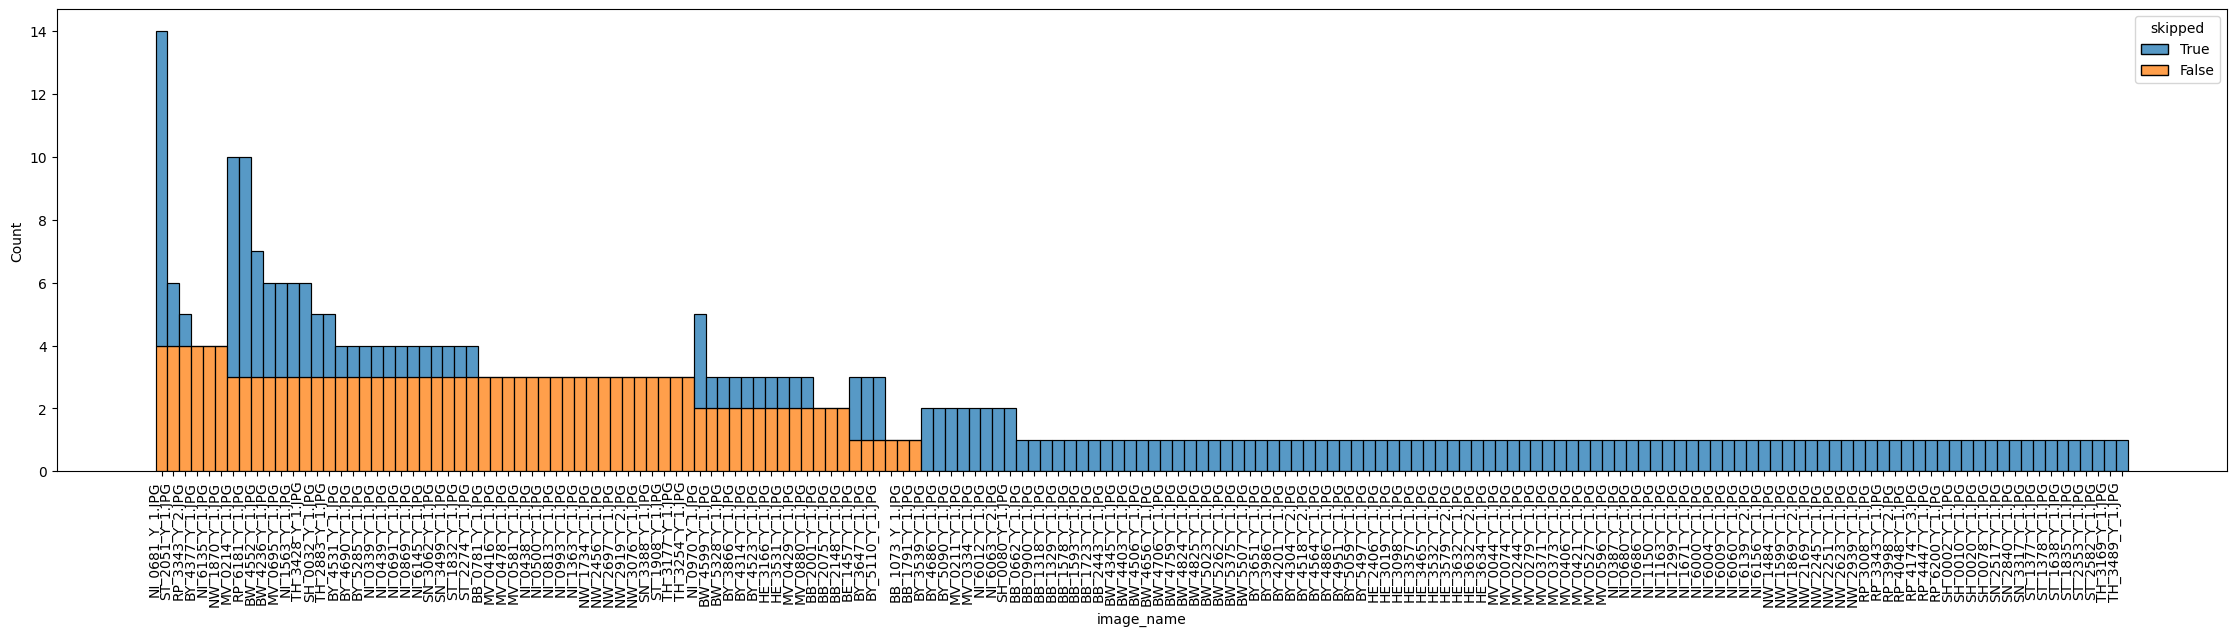

Number of images: 165
Distribution (non-skipped count -> #images):
False
0    101
1      6
2     13
3     39
4      6
Name: count, dtype: int64


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df_non_assisted
print("Distribution of annotations per image_name (non-ML assisted):")

plt.figure(figsize=(28, 6))
# rotate x-axis labels for better readability
plt.xticks(rotation=90, ha='right')
order = df.loc[~df['skipped'], 'image_name'].value_counts().sort_values(ascending=False).index.tolist()
# compute counts per image_name for both hue values
counts = df.groupby(['image_name', 'skipped']).size().unstack(fill_value=0)

# ensure columns exist
prim = counts[False] if False in counts.columns else pd.Series(0, index=counts.index)
sec = counts[True] if True in counts.columns else pd.Series(0, index=counts.index)

# sort by primary (non-skipped) descending, then by secondary (skipped) descending
order = sorted(counts.index, key=lambda n: (-int(prim.loc[n]), -int(sec.loc[n])))

# append any remaining names preserving original uniqueness
order += [n for n in df['image_name'].unique() if n not in order]
df['image_name'] = pd.Categorical(df['image_name'], categories=order, ordered=True)
sns.histplot(data=df, x='image_name', hue='skipped', multiple='stack', hue_order=[True, False])
plt.show()

# distribution of number of non-skipped annotations per image_name
dist = prim.value_counts().sort_index()
print("Number of images:", prim.size)
print("Distribution (non-skipped count -> #images):")
print(dist)

In [4]:
# image names with exactly 3 non-skipped annotations (uses existing `prim`)
img_names_3 = prim[prim == 3].index.tolist()

print(f"Images with 3 non-skipped annotations: {len(img_names_3)}")

# all rows for those images
df_3_non_skipped = df[df['image_name'].isin(img_names_3) & (~df['skipped'])].sort_values(['image_name', 'time_stamp'])
display(df_3_non_skipped)

Images with 3 non-skipped annotations: 39


,time_stamp,image_idx,image_name,anonId,skipped,depths,symbols,ml_assisted,ml_depths,ml_symbols
id,,,,,,,,,,
39,2025-11-06 14:18:18.075077,255,MV_0214_Y_1.JPG,89138847-ac09-4a58-9912-b308d7ac5f7f,False,"[0.22045454545454546, 0.4772727272727273, 0.69...","[Ah, E., E., Gw, Go]",False,[],[]
167,2025-11-17 08:12:21.683045,255,MV_0214_Y_1.JPG,52f0815d-26b9-4973-8074-97f587625f8a,False,[],[Sw-Ap],False,[],[]
275,2025-12-12 07:20:56.962178,255,MV_0214_Y_1.JPG,70d8591c-b52a-4081-9efb-732d6632f592,False,"[0.47045454545454546, 0.6590909090909091, 0.89...","[Axp, Ael-Bv, Bv-elC, Sw-ilC]",False,[],[]
42,2025-11-06 14:37:10.481752,513,RP_6181_Y_1.JPG,89138847-ac09-4a58-9912-b308d7ac5f7f,False,"[0.2318181818181818, 0.39090909090909093]","[Ah, M., ilC-Bv]",False,[],[]
163,2025-11-17 08:09:21.480204,513,RP_6181_Y_1.JPG,52f0815d-26b9-4973-8074-97f587625f8a,False,[],[Go],False,[],[]
...,...,...,...,...,...,...,...,...,...,...
182,2025-11-25 13:46:57.923108,661,TH_3177_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[],[Mc],False,[],[]
269,2025-12-04 15:00:28.065253,661,TH_3177_Y_1.JPG,2ec1d244-7a9b-444e-ba8d-165c9d19af26,False,[],[bE],False,[],[]
189,2025-11-25 13:54:57.564202,665,TH_3254_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[0.4515506625175476],"[Ah, Bv]",False,[],[]


In [5]:
import numpy as np
import torch
from torchvision import transforms
from PIL import Image

import sys
sys.path.append('./BGR')

from bgr.soil.modelling.soilnet import SoilNet_LSTM
from bgr.soil.data.horizon_tabular_data import HorizonDataProcessor
from bgr.soil.data.datasets import ImageTabularEnd2EndDataset
import bgr.soil.conformal as bgr_conform

IMAGE_PATH_COLUMN = 'file'
DEPTHS_COLUMN = 'Untergrenze'
LABELS_COLUMN = 'Horizontsymbol_relevant'

dataprocessor = HorizonDataProcessor(label_embeddings_path='BGR/label_embeddings/all_horizons_embeddings_thirds.pickle')
all_horizon_data = dataprocessor.load_processed_data()
_, _, test_data = dataprocessor.multi_label_stratified_shuffle_split(
    all_horizon_data,
    train_val_test_frac=[0.6, 0.2, 0.2], # Dont change this!
    random_state=2025 # Dont change this!
)

test_data.reset_index(drop=True, inplace=True)

In [6]:
import pickle

class Predictions_Interface:
    def __init__(self, preds_pickle):        
        with open(preds_pickle, 'rb') as f:
            preds_dict = pickle.load(f)
            # {
            #     'segment_geotemp_features_test': segment_geotemp_features_test,
            #     'all_pred_depths_test': all_pred_depths_test,
            #     'all_true_depths_test': all_true_depths_test,
            #     'all_pred_logits_test': all_pred_logits_test,
            #     'all_true_hor_inds_test': all_true_hor_inds_test
            # }
        
        segment_geotemp_features_test = preds_dict['segment_geotemp_features_test']
        all_pred_depths_test = preds_dict['all_pred_depths_test']
        all_true_depths_test = preds_dict['all_true_depths_test']
        all_pred_logits_test = preds_dict['all_pred_logits_test']
        all_true_hor_inds_test = preds_dict['all_true_hor_inds_test']
        
        # Concatenattions/Aggregations
        self.all_true_depths_test = np.concatenate(all_true_depths_test, axis=0)
        self.all_pred_depths_test = np.concatenate(all_pred_depths_test, axis=0)

        segment_geotemp_list_test = [item for sublist in segment_geotemp_features_test for item in sublist]
        self.trimmed_true_depths_stacked_test, \
            self.trimmed_pred_depths_stacked_test, \
                segment_geotemp_concat_test   = bgr_conform.trim_concat(self.all_true_depths_test, self.all_pred_depths_test, segment_geotemp_list_test)
        
        self.all_true_hor_inds_test = torch.from_numpy(np.concatenate(all_true_hor_inds_test, axis=0))
        all_pred_logits_test = torch.from_numpy(np.concatenate(all_pred_logits_test, axis=0))
        self.all_pred_hor_inds_test = np.argmax(all_pred_logits_test, axis=1)
        
    def get_trues_and_preds_by_imgpath(self, img_path):
        ex_ind = test_data.index[test_data[IMAGE_PATH_COLUMN] == img_path].tolist()[0]
        print(ex_ind)
        
        # Get index of the stop token of the chosen example
        stop_token_occurrences = (self.trimmed_true_depths_stacked_test == 1.0).nonzero(as_tuple=True)[0]
        top_ind, bottom_ind = stop_token_occurrences[ex_ind-1]+1 if ex_ind > 0 else 0, stop_token_occurrences[ex_ind]+1
        print(top_ind, bottom_ind)
        
        pred_depths = self.trimmed_pred_depths_stacked_test[top_ind:bottom_ind].cpu().numpy()
        pred_hor_inds = self.all_pred_hor_inds_test[top_ind:bottom_ind].cpu().numpy()
        pred_symbols = [dataprocessor.embeddings_dict['ind2label'][ind] for ind in pred_hor_inds] # type: ignore
        
        true_depths = self.trimmed_true_depths_stacked_test[top_ind:bottom_ind].cpu().numpy()
        true_hor_inds = self.all_true_hor_inds_test[top_ind:bottom_ind].cpu().numpy()
        true_symbols = [dataprocessor.embeddings_dict['ind2label'][ind] for ind in true_hor_inds] # type: ignore
        
        # Alignment with the user annotation:
        if pred_depths[-1] == 1.0:
            pred_depths = pred_depths[:-1]
        if true_depths[-1] == 1.0:
            true_depths = true_depths[:-1]
        
        print("Predictions:")
        print(pred_depths)
        print(pred_symbols)
        print("Ground Truths:")
        print(true_depths)
        print(true_symbols)
        # pred_depths = pred_depths[pred_depths != 1.0]
        # pred_symbols = pred_symbols[:len(pred_depths) + 1]
        
        # true_depths = true_depths[true_depths != 1.0]
        # true_symbols = true_symbols[:len(true_depths) + 1]
        
        return pred_depths, pred_symbols, true_depths, true_symbols
        

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

def plot_annotation(ax, img, depths, symbols, title=None):
    w, h = img.size
    y_lines = sorted(float(d) * h for d in depths)
    ax.imshow(img)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11)

    # boundary lines
    for y in y_lines:
        ax.axhline(y, color="cyan", lw=2, ls="--")

    # segment centers + labels
    boundaries = [0.0] + y_lines + [h]
    centers = [(a + b) / 2 for a, b in zip(boundaries[:-1], boundaries[1:])]
    for y, sym in zip(centers, symbols):
        ax.text(
            w / 2,
            y,
            sym,
            ha="center",
            va="center",
            color="white",
            fontsize=16,
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2"),
        )

Results for image: ../data/BGR/Profilbilder_no_ruler_no_sky/BY_4025_Y_1.JPG
Error processing image ../data/BGR/Profilbilder_no_ruler_no_sky/BY_4025_Y_1.JPG: list index out of range
Results for image: ../data/BGR/Profilbilder_no_ruler_no_sky/BY_4311_Y_1.JPG
Error processing image ../data/BGR/Profilbilder_no_ruler_no_sky/BY_4311_Y_1.JPG: list index out of range
Results for image: ../data/BGR/Profilbilder_no_ruler_no_sky/BY_4518_Y_1.JPG
Error processing image ../data/BGR/Profilbilder_no_ruler_no_sky/BY_4518_Y_1.JPG: list index out of range
Results for image: ../data/BGR/Profilbilder_no_ruler_no_sky/BY_4518_Y_2.JPG
143
tensor(599) tensor(603)
Predictions:
[0.200426  0.4648571 0.7412019]
['Ap', 'M.', 'M.', 'M.']
Ground Truths:
[0.33 0.73 0.81]
['Ap', 'M.', 'Ah', 'Sw']


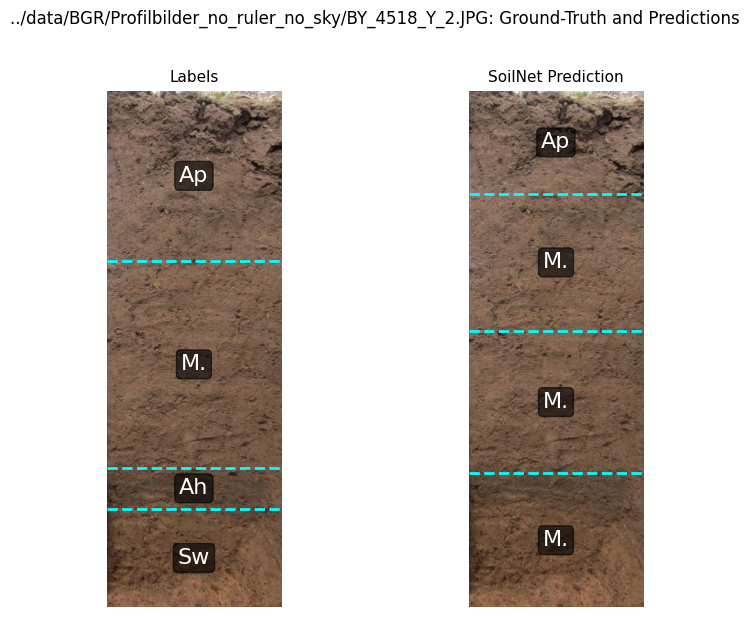



Results for image: ../data/BGR/Profilbilder_no_ruler_no_sky/BY_4695_Y_1.JPG
156
tensor(654) tensor(659)
Predictions:
[0.1397353  0.33171847 0.54495096 0.76716113]
['Ah', 'Ap', 'Bv', 'Bv', 'ilC']
Ground Truths:
[0.14 0.38 0.73 0.96]
['Ah', 'Ah', 'Bv', 'ilC', 'ilC']


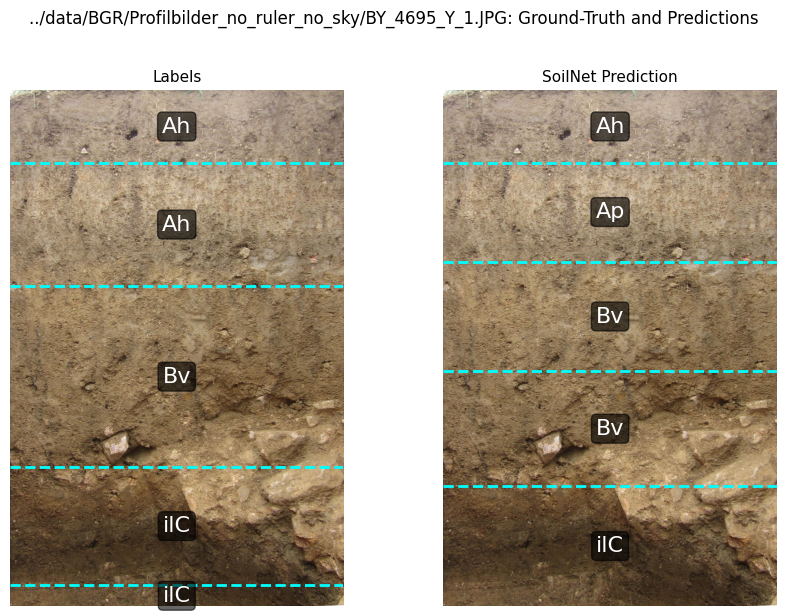



Results for image: ../data/BGR/Profilbilder_no_ruler_no_sky/BW_4752_Y_1.JPG
Error processing image ../data/BGR/Profilbilder_no_ruler_no_sky/BW_4752_Y_1.JPG: list index out of range
Results for image: ../data/BGR/Profilbilder_no_ruler_no_sky/BW_5227_Y_1.JPG
Error processing image ../data/BGR/Profilbilder_no_ruler_no_sky/BW_5227_Y_1.JPG: list index out of range


In [8]:
predictions_and_trues_interface = Predictions_Interface("predictions_test.pickle")

image1 = '../data/BGR/Profilbilder_no_ruler_no_sky/BY_4025_Y_1.JPG'
image2 = '../data/BGR/Profilbilder_no_ruler_no_sky/BY_4311_Y_1.JPG'
image3 = '../data/BGR/Profilbilder_no_ruler_no_sky/BY_4518_Y_1.JPG'
image4 = '../data/BGR/Profilbilder_no_ruler_no_sky/BY_4518_Y_2.JPG'
image5 = '../data/BGR/Profilbilder_no_ruler_no_sky/BY_4695_Y_1.JPG'
image6 = '../data/BGR/Profilbilder_no_ruler_no_sky/BW_4752_Y_1.JPG'
image7 = '../data/BGR/Profilbilder_no_ruler_no_sky/BW_5227_Y_1.JPG'

images = [image1, image2, image3, image4, image5, image6, image7]

for img_path in images:
    print(f"Results for image: {img_path}")
    try:
        pred_depths, pred_symbols, true_depths, true_symbols = predictions_and_trues_interface.get_trues_and_preds_by_imgpath(img_path)
        
        tracks = [
        ("Labels", true_depths, true_symbols),
        ("SoilNet Prediction", pred_depths, pred_symbols),
        ]
        
        n = len(tracks)
        fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 6))
        if n == 1:
            axes = [axes]

        img = Image.open(img_path)
        for ax, (title, depths, symbols) in zip(axes, tracks):
            plot_annotation(ax, img, depths, symbols, title=title)

        fig.suptitle(f"{img_path}: Ground-Truth and Predictions", y=1.02)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error processing image {img_path}: {e}")
        continue
    print("\n")

203
tensor(841) tensor(846)
Predictions:
[0.14968064 0.351156   0.56929713 0.7919736 ]
['Ah', 'Ap', 'Sw-Bv', 'Sd', 'Sd']
Ground Truths:
[0.09 0.38 0.52 0.76]
['Ah', 'Ap', 'Al-Bv', 'Btv', 'Sd']


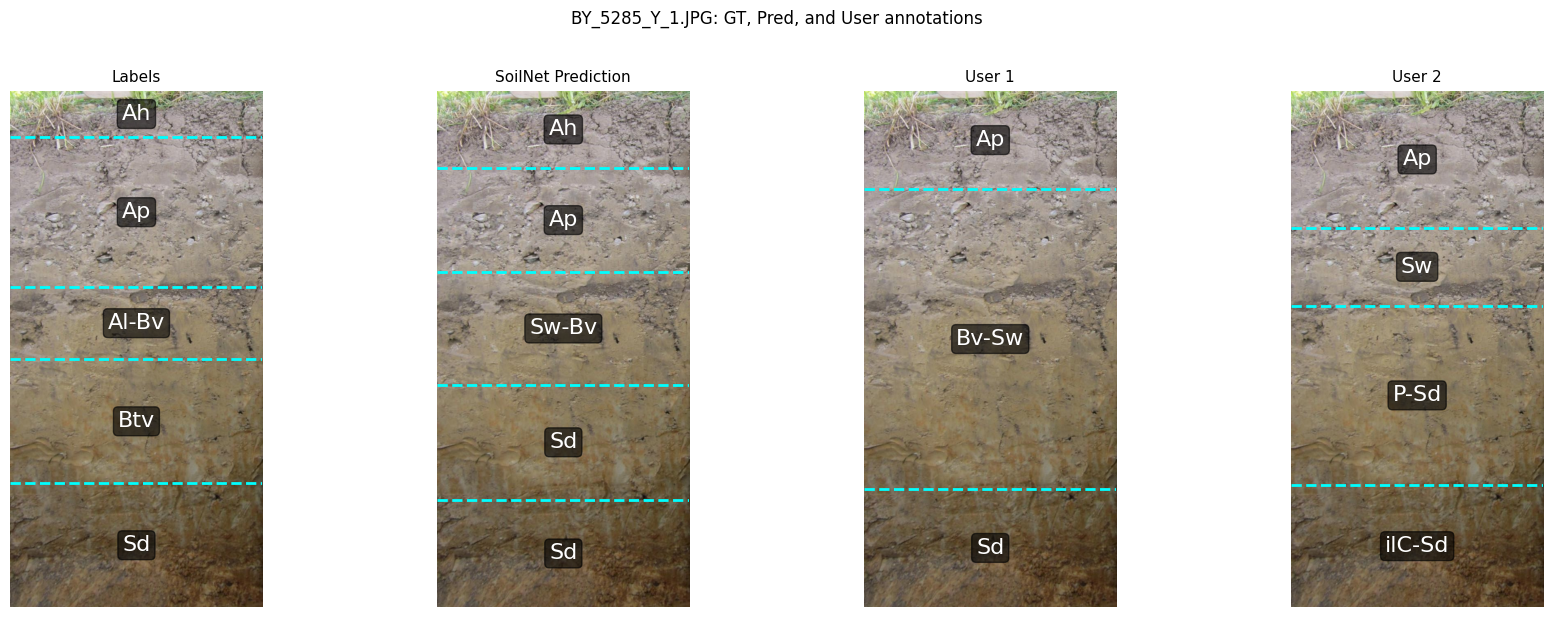

Saved: sample_images/labels_BY_5285_Y_1.jpg
Saved: sample_images/soilnet_prediction_BY_5285_Y_1.jpg
Saved: sample_images/user_1_BY_5285_Y_1.jpg
Saved: sample_images/user_2_BY_5285_Y_1.jpg
304
tensor(1235) tensor(1240)
Predictions:
[0.20063286 0.43940327 0.66551983 0.8718983 ]
['Ap', 'Ap', 'Go', 'Go', 'Go']
Ground Truths:
[0.4  0.53 0.73 0.97]
['Ap', 'Bhs', 'Go', 'Go', 'Gor']


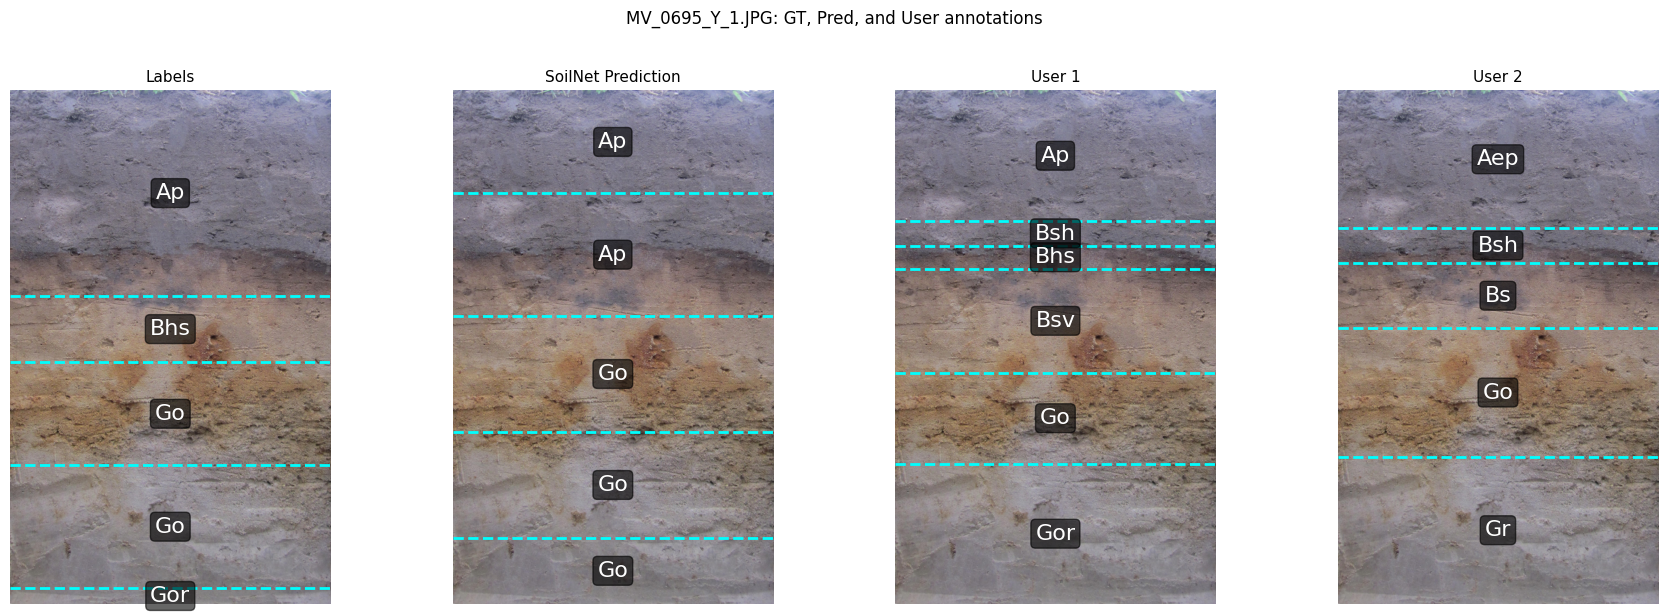

Saved: sample_images/labels_MV_0695_Y_1.jpg
Saved: sample_images/soilnet_prediction_MV_0695_Y_1.jpg
Saved: sample_images/user_1_MV_0695_Y_1.jpg
Saved: sample_images/user_2_MV_0695_Y_1.jpg


In [9]:
predictions_and_trues_interface = Predictions_Interface("predictions_test.pickle")

import matplotlib.pyplot as plt
from PIL import Image

def plot_annotation(ax, img, depths, symbols, title=None):
    w, h = img.size
    y_lines = sorted(float(d) * h for d in depths)
    ax.imshow(img)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11)

    # boundary lines
    for y in y_lines:
        ax.axhline(y, color="cyan", lw=2, ls="--")

    # segment centers + labels
    boundaries = [0.0] + y_lines + [h]
    centers = [(a + b) / 2 for a, b in zip(boundaries[:-1], boundaries[1:])]
    for y, sym in zip(centers, symbols):
        ax.text(
            w / 2,
            y,
            sym,
            ha="center",
            va="center",
            color="white",
            fontsize=16,
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2"),
        )

image_folder_path = "../data/BGR/Profilbilder_no_ruler_no_sky"

for img_name in ("BY_5285_Y_1.JPG", "MV_0695_Y_1.JPG"):
    subset = df_3_non_skipped[df_3_non_skipped["image_name"] == img_name]
    if subset.empty:
        continue

    img_path = os.path.join(image_folder_path, img_name)
    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        continue

    # preds/truths; returns preds first, then truths
    pred_depths, pred_symbols, true_depths, true_symbols = (
        predictions_and_trues_interface.get_trues_and_preds_by_imgpath(img_path)
    )

    tracks = [
        ("Labels", true_depths, true_symbols),
        ("SoilNet Prediction", pred_depths, pred_symbols),
    ]
    user_num = 1
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        if i == 2:  # Skip User 2 (is an outlier)
            continue
        
        tracks.append((f"User {user_num}", row["depths"], row["symbols"]))
        user_num += 1
    n = len(tracks)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 6))
    if n == 1:
        axes = [axes]

    img = Image.open(img_path)
    for ax, (title, depths, symbols) in zip(axes, tracks):
        plot_annotation(ax, img, depths, symbols, title=title)

    fig.suptitle(f"{img_name}: GT, Pred, and User annotations", y=1.02)
    plt.tight_layout()
    plt.show()

    # save each sub-image individually
    base_name = os.path.splitext(img_name)[0]
    for title, depths, symbols in tracks:
        # create a filesystem-friendly prefix from the title
        prefix = title.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_").replace(":", "")
        out_fname = f"{prefix}_{base_name}.jpg"
        out_path = os.path.join('sample_images', out_fname)

        fig_single, ax_single = plt.subplots(1, 1, figsize=(4.5, 6))
        plot_annotation(ax_single, img, depths, symbols)
        plt.tight_layout()
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        pdf_path = os.path.splitext(out_path)[0] + '.pdf'
        fig_single.savefig(pdf_path, dpi=300, bbox_inches="tight")
        plt.close(fig_single)
        print(f"Saved: {out_path}")

In [10]:
def _prep_depths(depths):
    """Clean, sort, and add 0/1 boundaries."""
    if depths is None:
        depths = []
    cleaned = [float(d) for d in depths if d is not None]
    cleaned = [d for d in cleaned if 0.0 <= d <= 1.0]
    cleaned.sort()
    if not cleaned or cleaned[-1] < 1.0:
        cleaned.append(1.0)        # stop token / bottom
    return [0.0] + cleaned         # top

def depth_iou_lists(pred_depths, true_depths):
    p = _prep_depths(pred_depths)
    t = _prep_depths(true_depths)
    n_segments = min(len(p), len(t)) - 1
    if n_segments <= 0:
        return 0.0

    ious = []
    for i in range(n_segments):
        pa, pb = p[i], p[i+1]
        ta, tb = t[i], t[i+1]
        inter = max(0.0, min(pb, tb) - max(pa, ta))
        union = max(pb, tb) - min(pa, ta)
        ious.append(inter / union if union > 0 else 0.0)

    return sum(ious) / n_segments

def user_depth_iou(image_path, user_depths, test_data, col="Untergrenze"):
    """Find the row in test_data and compute IoU against the user list."""
    row = test_data.loc[test_data["file"] == image_path]
    if row.empty:
        raise ValueError(f"No sample found for image_path={image_path}")
    true_depths = row.iloc[0][col]
    return depth_iou_lists(user_depths, true_depths)


In [11]:
df_non_skipped = df[~df['skipped']]
df_non_skipped.reset_index(drop=True, inplace=True)

image_folder_path = "../data/BGR/Profilbilder_no_ruler_no_sky"
ious = []
for row in df_non_skipped.itertuples():
    img_name = row.image_name
    img_path = os.path.join(image_folder_path, img_name)
    user_depths = row.depths
    
    try:
        iou = user_depth_iou(img_path, user_depths, test_data)
        print(f"User {row.anonId} IoU for {img_name}: {iou:.4f}")
        ious.append(iou)
    except ValueError as e:
        print(e)

if ious:
    avg_iou = sum(ious) / len(ious)
    print(f"Average IoU across all users and images: {avg_iou:.4f}")

User 4bfccfa8-02f8-4ffe-907c-35e836fe46b1 IoU for RP_3343_Y_2.JPG: 0.4748
User 4bfccfa8-02f8-4ffe-907c-35e836fe46b1 IoU for NI_0439_Y_1.JPG: 0.4424
User bedaf05b-d9c4-4566-8b5c-832269dd9a12 IoU for RP_3343_Y_2.JPG: 0.5301
User bedaf05b-d9c4-4566-8b5c-832269dd9a12 IoU for BY_4531_Y_1.JPG: 0.4717
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb IoU for NI_0439_Y_1.JPG: 0.4568
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb IoU for BY_4377_Y_1.JPG: 0.4967
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb IoU for ST_2274_Y_1.JPG: 0.9291
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb IoU for BB_0781_Y_1.JPG: 0.9559
User 89138847-ac09-4a58-9912-b308d7ac5f7f IoU for RP_3343_Y_2.JPG: 0.5033
User 89138847-ac09-4a58-9912-b308d7ac5f7f IoU for NI_0439_Y_1.JPG: 0.5944
User 89138847-ac09-4a58-9912-b308d7ac5f7f IoU for ST_2274_Y_1.JPG: 0.9281
User 89138847-ac09-4a58-9912-b308d7ac5f7f IoU for BY_4531_Y_1.JPG: 0.6616
User 89138847-ac09-4a58-9912-b308d7ac5f7f IoU for BY_4377_Y_1.JPG: 0.6047
User 89138847-ac09-4a58-9912-b308d7ac5

In [12]:
import re
import numpy as np

def _clean_symbol(s):
    return str(s).strip().strip("'\"")

def _main_symbol(s):
    label = _clean_symbol(s)
    caps = re.findall(r"[A-Z]", label)
    return caps[-1] if caps else (label[0] if label else "")

def user_symbol_accuracy(user_symbols, true_hor_inds, emb_dict):
    """Returns (full_symbol_acc, main_symbol_acc) plus a small info dict."""
    true_symbols = [emb_dict["ind2label"][i] for i in true_hor_inds]
    n = min(len(user_symbols), len(true_symbols))
    if n == 0:
        return 0.0, 0.0, {"used_segments": 0}

    user_clean = [_clean_symbol(s) for s in user_symbols[:n]]
    true_clean = [_clean_symbol(s) for s in true_symbols[:n]]

    full_acc = float(np.mean([u == t for u, t in zip(user_clean, true_clean)]))
    main_acc = float(np.mean([_main_symbol(u) == _main_symbol(t) for u, t in zip(user_clean, true_clean)]))

    return full_acc, main_acc, {
        "used_segments": n,
        "user_symbols_used": user_clean,
        "true_symbols_used": true_clean,
        "user_main": [_main_symbol(s) for s in user_clean],
        "true_main": [_main_symbol(s) for s in true_clean],
    }

In [13]:
full_accuracies = []
main_accuracies = []

for row in df_non_skipped.itertuples():
    img_name = row.image_name
    img_path = os.path.join(image_folder_path, img_name)
    user_symbols = row.symbols
    
    try:
        row_test = test_data.loc[test_data["file"] == img_path]
        if row_test.empty:
            print(f"No sample found for image_path={img_path}")
            continue
        true_hor_inds = row_test.iloc[0]["Horizontsymbol_relevant"]
        
        full_acc, main_acc, info = user_symbol_accuracy(user_symbols, true_hor_inds, dataprocessor.embeddings_dict)
        full_accuracies.append(full_acc)
        main_accuracies.append(main_acc)
        print(f"User {row.anonId} Symbol Accuracy for {img_name}: Full={full_acc:.4f}, Main={main_acc:.4f}")
    except ValueError as e:
        print(e)
        
if full_accuracies:
    avg_full_acc = sum(full_accuracies) / len(full_accuracies)
    avg_main_acc = sum(main_accuracies) / len(main_accuracies)
    print(f"Average Full Symbol Accuracy: {avg_full_acc:.4f}")
    print(f"Average Main Symbol Accuracy: {avg_main_acc:.4f}")

User 4bfccfa8-02f8-4ffe-907c-35e836fe46b1 Symbol Accuracy for RP_3343_Y_2.JPG: Full=0.0000, Main=1.0000
User 4bfccfa8-02f8-4ffe-907c-35e836fe46b1 Symbol Accuracy for NI_0439_Y_1.JPG: Full=0.3333, Main=1.0000
User bedaf05b-d9c4-4566-8b5c-832269dd9a12 Symbol Accuracy for RP_3343_Y_2.JPG: Full=0.3333, Main=1.0000
User bedaf05b-d9c4-4566-8b5c-832269dd9a12 Symbol Accuracy for BY_4531_Y_1.JPG: Full=0.3333, Main=0.3333
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb Symbol Accuracy for NI_0439_Y_1.JPG: Full=0.0000, Main=0.6667
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb Symbol Accuracy for BY_4377_Y_1.JPG: Full=0.3333, Main=0.3333
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb Symbol Accuracy for ST_2274_Y_1.JPG: Full=0.5000, Main=1.0000
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb Symbol Accuracy for BB_0781_Y_1.JPG: Full=0.5000, Main=0.5000
User 89138847-ac09-4a58-9912-b308d7ac5f7f Symbol Accuracy for RP_3343_Y_2.JPG: Full=0.3333, Main=0.6667
User 89138847-ac09-4a58-9912-b308d7ac5f7f Symbol Accuracy for NI

/var/folders/gt/zszlf_dx519294b6bw7dbv0h0000gn/T/ipykernel_70806/171633974.py:17: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(wspace=0.35)


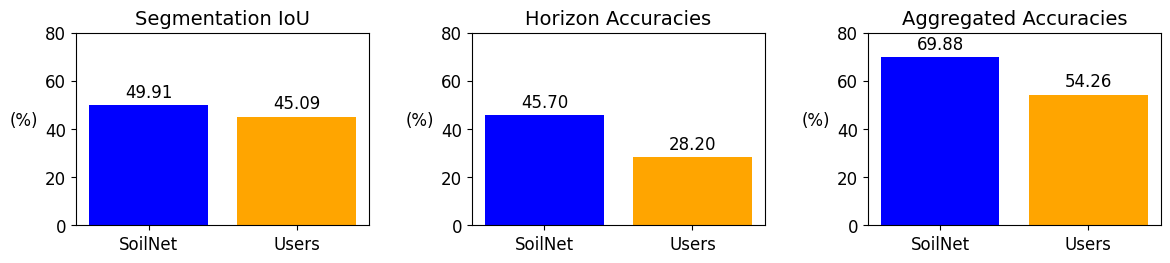

In [14]:
ious = {
    'SoilNet': 49.91,
    'Users' : round(avg_iou * 100, 2)
}
full_accuracies = {
    'SoilNet': 45.7,
    'Users' : round(avg_full_acc * 100, 2)
}
main_accuracies = {
    'SoilNet': 69.88,
    'Users' : round(avg_main_acc * 100, 2)
}

import matplotlib.pyplot as plt
# increase horizontal spacing between the three subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 2.5), constrained_layout=True)
fig.subplots_adjust(wspace=0.35)
colors = ['blue', 'orange']

ylim = 80
for ax, data, title in zip(
    axes,
    [ious, full_accuracies, main_accuracies],
    ['Segmentation IoU', 'Horizon Accuracies', 'Aggregated Accuracies']
):    
    keys = list(data.keys())
    vals = list(data.values())
    ax.bar(keys, vals, color=colors)
    ax.set_title(title)
    ax.title.set_fontsize(14)
    ax.set_ylim(0, ylim)
    ax.set_ylabel('(%)', fontsize=12)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.labelpad = 15
    ax.tick_params(axis='both', which='major', labelsize=12)
    # annotate bars
    for i, v in enumerate(vals):
        ax.text(i, v + ylim * 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=12)

pdf_path = 'sample_images/summary_metrics.pdf'
plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
plt.show()

In [15]:
df[(df['anonId'] == '4b5d3eac-33f7-4e19-83f6-b91e55f6b578') & (~df['skipped'])]

,time_stamp,image_idx,image_name,anonId,skipped,depths,symbols,ml_assisted,ml_depths,ml_symbols
id,,,,,,,,,,
182,2025-11-25 13:46:57.923108,661,TH_3177_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[],[Mc],False,[],[]
183,2025-11-25 13:48:40.229118,411,NI_6135_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,"[0.2507931795987216, 0.4755406466397372]","[Ap, Sw-Bv, Sd]",False,[],[]
184,2025-11-25 13:49:42.072686,280,MV_0416_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[0.5677123503251509],"[M., lC]",False,[],[]
185,2025-11-25 13:50:22.047935,58,BW_4552_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[0.20786384235728872],"[Ap, Sd]",False,[],[]
186,2025-11-25 13:50:50.394627,586,SN_3388_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[0.14220731908624823],"[Ah, Bv]",False,[],[]
187,2025-11-25 13:51:40.673947,288,MV_0478_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,"[0.3088739048350941, 0.4957426071166992, 0.596...","[Ah, Bv, E., Bt]",False,[],[]
188,2025-11-25 13:53:02.388595,463,NW_2697_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[],[Ah-Bv],False,[],[]
189,2025-11-25 13:54:57.564202,665,TH_3254_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[0.4515506625175476],"[Ah, Bv]",False,[],[]
190,2025-11-25 13:55:34.371109,104,BY_3647_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[],[Axh],False,[],[]


In [16]:
# Find distinct users and number of annotations in the dataset
distinct_users = df_non_skipped['anonId'].nunique()
annotations_per_user = df_non_skipped.groupby('anonId').size()
print(f"Distinct users: {distinct_users}")
print("Annotations per user:")
print(annotations_per_user)

print("Average annotations per user:", annotations_per_user.mean())
print("Q25 annotations per user:", annotations_per_user.quantile(0.25))
print("Median annotations per user:", annotations_per_user.median())
print("Q75 annotations per user:", annotations_per_user.quantile(0.75))

Distinct users: 23
Annotations per user:
anonId
031d3b2d-e697-4339-a80d-6ad5d76de91f     1
2ab9dd0b-70c5-454c-aca6-414e1802b0f9     1
2ec1d244-7a9b-444e-ba8d-165c9d19af26     1
3369cec8-47c2-4421-ac66-33a034dc4b67     8
3c93194e-c40d-408d-8a35-4e2bebc1a551     1
4b5d3eac-33f7-4e19-83f6-b91e55f6b578    47
4bfccfa8-02f8-4ffe-907c-35e836fe46b1     3
52f0815d-26b9-4973-8074-97f587625f8a     7
5cfcc301-8fda-40ee-967e-7655283c8cd4     9
70d8591c-b52a-4081-9efb-732d6632f592    27
714fae50-7c7a-4ef4-8191-d9d893d4fdd6     1
729f9836-70b7-4119-b4b7-f0d9d3e3702b     5
7671f031-bf25-4e3d-a32f-b9eac573b10a    24
89138847-ac09-4a58-9912-b308d7ac5f7f    18
99eff31c-15dc-407a-8bc0-ac4bf3581436     2
aa4bc528-5f3b-4d19-9b10-9f6d00356edb     4
ac0b3715-2621-40cd-a75d-780908cbc84c     2
b646ab25-7fd7-4cfd-97fc-91d235d1e23f     2
bedaf05b-d9c4-4566-8b5c-832269dd9a12     2
c4b6847e-9fc6-4110-aaa4-9a17366170dc     1
d595d4f6-a471-45d8-b939-414bb0184e8b     5
dcda5e0e-e629-4133-9763-f7944f132b66     1
user-1

Distribution of annotations per image_name (ML assisted):


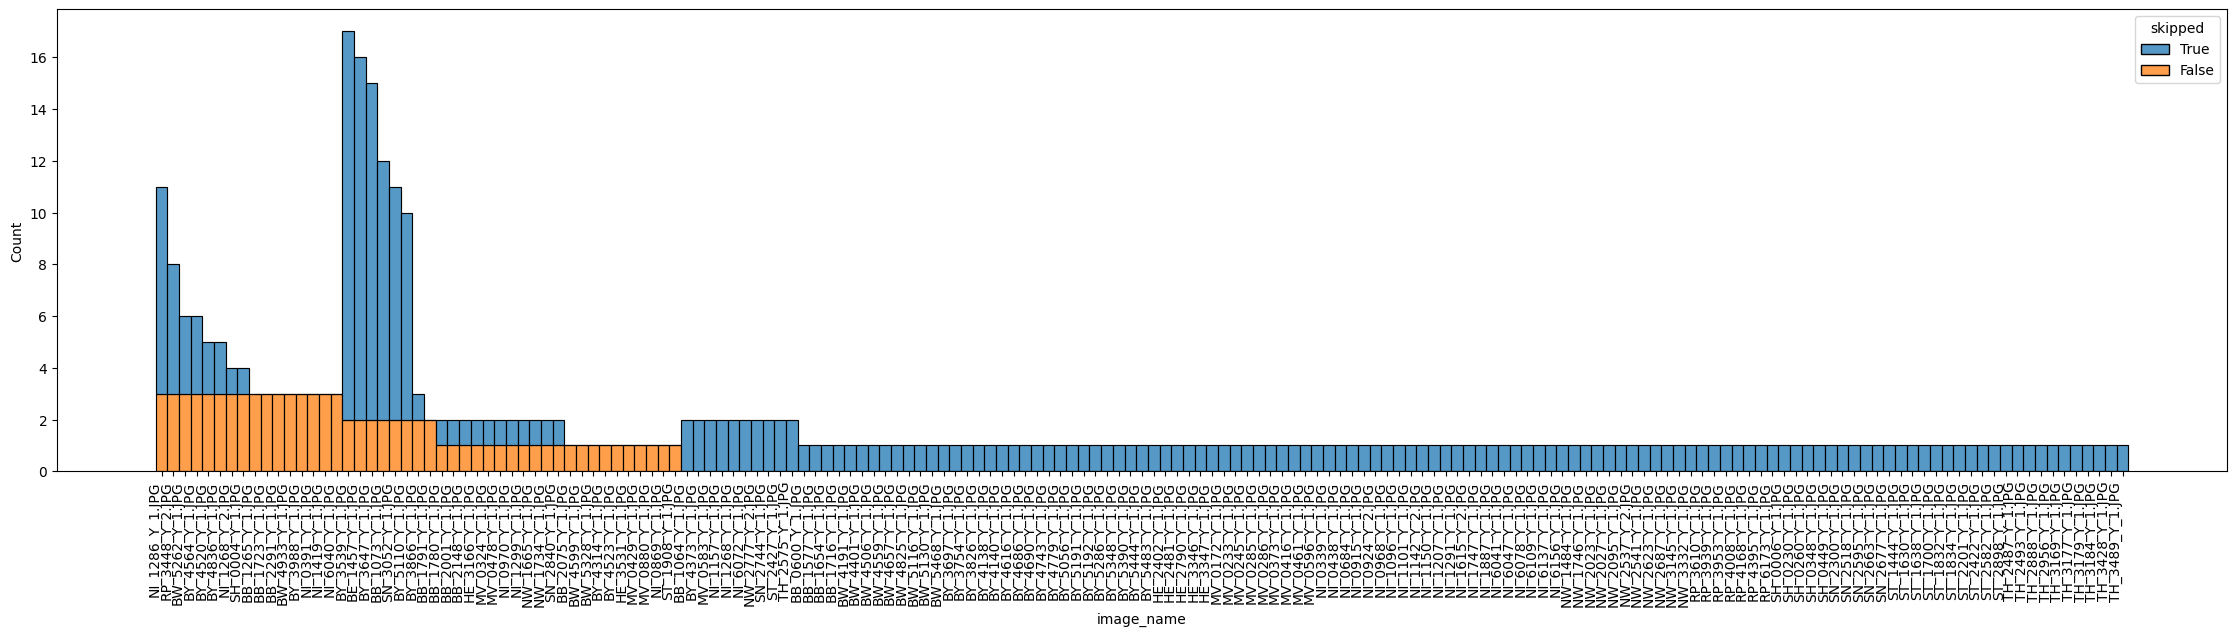

Number of images: 169
Distribution (non-skipped count -> #images):
False
0    124
1     21
2      8
3     16
Name: count, dtype: int64


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df_ml_assisted
print("Distribution of annotations per image_name (ML assisted):")

plt.figure(figsize=(28, 6))
# rotate x-axis labels for better readability
plt.xticks(rotation=90, ha='right')
order = df.loc[~df['skipped'], 'image_name'].value_counts().sort_values(ascending=False).index.tolist()
# compute counts per image_name for both hue values
counts = df.groupby(['image_name', 'skipped']).size().unstack(fill_value=0)

# ensure columns exist
prim = counts[False] if False in counts.columns else pd.Series(0, index=counts.index)
sec = counts[True] if True in counts.columns else pd.Series(0, index=counts.index)

# sort by primary (non-skipped) descending, then by secondary (skipped) descending
order = sorted(counts.index, key=lambda n: (-int(prim.loc[n]), -int(sec.loc[n])))

# append any remaining names preserving original uniqueness
order += [n for n in df['image_name'].unique() if n not in order]
df['image_name'] = pd.Categorical(df['image_name'], categories=order, ordered=True)
sns.histplot(data=df, x='image_name', hue='skipped', multiple='stack', hue_order=[True, False])
plt.show()

# distribution of number of non-skipped annotations per image_name
dist = prim.value_counts().sort_index()
print("Number of images:", prim.size)
print("Distribution (non-skipped count -> #images):")
print(dist)

In [18]:
df_non_skipped = df[~df['skipped']]
df_non_skipped.reset_index(drop=True, inplace=True)

image_folder_path = "../data/BGR/Profilbilder_no_ruler_no_sky"
ious = []
for row in df_non_skipped.itertuples():
    img_name = row.image_name
    img_path = os.path.join(image_folder_path, img_name)
    user_depths = row.depths
    
    try:
        iou = user_depth_iou(img_path, user_depths, test_data)
        print(f"User {row.anonId} IoU for {img_name}: {iou:.4f}")
        ious.append(iou)
    except ValueError as e:
        print(e)

if ious:
    avg_iou = sum(ious) / len(ious)
    print(f"Average IoU across all users and images: {avg_iou:.4f}")
    
full_accuracies = []
main_accuracies = []

for row in df_non_skipped.itertuples():
    img_name = row.image_name
    img_path = os.path.join(image_folder_path, img_name)
    user_symbols = row.symbols
    
    try:
        row_test = test_data.loc[test_data["file"] == img_path]
        if row_test.empty:
            print(f"No sample found for image_path={img_path}")
            continue
        true_hor_inds = row_test.iloc[0]["Horizontsymbol_relevant"]
        
        full_acc, main_acc, info = user_symbol_accuracy(user_symbols, true_hor_inds, dataprocessor.embeddings_dict)
        full_accuracies.append(full_acc)
        main_accuracies.append(main_acc)
        print(f"User {row.anonId} Symbol Accuracy for {img_name}: Full={full_acc:.4f}, Main={main_acc:.4f}")
    except ValueError as e:
        print(e)
        
if full_accuracies:
    avg_full_acc = sum(full_accuracies) / len(full_accuracies)
    avg_main_acc = sum(main_accuracies) / len(main_accuracies)
    print(f"Average Full Symbol Accuracy: {avg_full_acc:.4f}")
    print(f"Average Main Symbol Accuracy: {avg_main_acc:.4f}")

# Find distinct users and number of annotations in the dataset
distinct_users = df_non_skipped['anonId'].nunique()
annotations_per_user = df_non_skipped.groupby('anonId').size()
print(f"Distinct users: {distinct_users}")
print("Annotations per user:")
print(annotations_per_user)

print("Average annotations per user:", annotations_per_user.mean())
print("Q25 annotations per user:", annotations_per_user.quantile(0.25))
print("Median annotations per user:", annotations_per_user.median())
print("Q75 annotations per user:", annotations_per_user.quantile(0.75))

User 5457af96-fa4b-4780-b362-af71266b4dbf IoU for NI_0970_Y_1.JPG: 0.4983
User 5457af96-fa4b-4780-b362-af71266b4dbf IoU for MV_0880_Y_1.JPG: 0.1226
User 5457af96-fa4b-4780-b362-af71266b4dbf IoU for MV_0429_Y_1.JPG: 0.6429
User 5457af96-fa4b-4780-b362-af71266b4dbf IoU for HE_3531_Y_1.JPG: 0.6350
User 5457af96-fa4b-4780-b362-af71266b4dbf IoU for HE_3166_Y_1.JPG: 0.5197
User 5457af96-fa4b-4780-b362-af71266b4dbf IoU for BY_4523_Y_1.JPG: 0.1841
User 5457af96-fa4b-4780-b362-af71266b4dbf IoU for BY_4314_Y_1.JPG: 0.0665
User 5457af96-fa4b-4780-b362-af71266b4dbf IoU for BY_3866_Y_1.JPG: 0.5573
User 5457af96-fa4b-4780-b362-af71266b4dbf IoU for BW_5328_Y_1.JPG: 0.1300
User 5457af96-fa4b-4780-b362-af71266b4dbf IoU for BW_4599_Y_1.JPG: 0.8165
User 3613e9e3-2e30-454a-b1ad-adfbd0dcd683 IoU for BB_2148_Y_1.JPG: 0.2006
User 53972387-c939-4f5e-aeb2-0ef26bf664cc IoU for BB_2075_Y_1.JPG: 0.5408
User 89138847-ac09-4a58-9912-b308d7ac5f7f IoU for BB_2001_Y_1.JPG: 0.1744
User 89138847-ac09-4a58-9912-b308d7ac5

/var/folders/gt/zszlf_dx519294b6bw7dbv0h0000gn/T/ipykernel_70806/171633974.py:17: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(wspace=0.35)


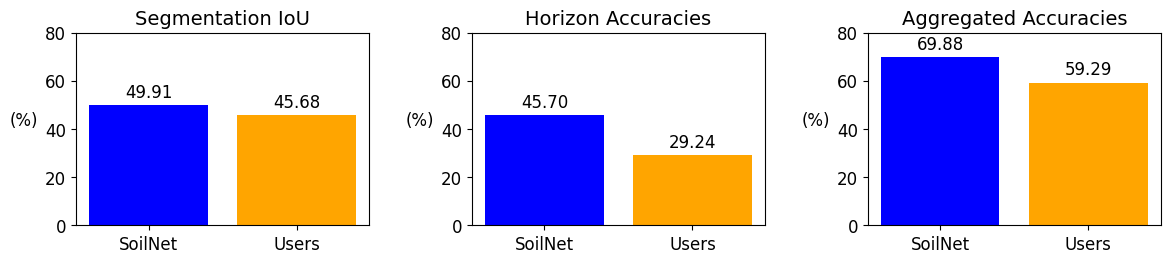

In [19]:
ious = {
    'SoilNet': 49.91,
    'Users' : round(avg_iou * 100, 2)
}
full_accuracies = {
    'SoilNet': 45.7,
    'Users' : round(avg_full_acc * 100, 2)
}
main_accuracies = {
    'SoilNet': 69.88,
    'Users' : round(avg_main_acc * 100, 2)
}

import matplotlib.pyplot as plt
# increase horizontal spacing between the three subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 2.5), constrained_layout=True)
fig.subplots_adjust(wspace=0.35)
colors = ['blue', 'orange']

ylim = 80
for ax, data, title in zip(
    axes,
    [ious, full_accuracies, main_accuracies],
    ['Segmentation IoU', 'Horizon Accuracies', 'Aggregated Accuracies']
):    
    keys = list(data.keys())
    vals = list(data.values())
    ax.bar(keys, vals, color=colors)
    ax.set_title(title)
    ax.title.set_fontsize(14)
    ax.set_ylim(0, ylim)
    ax.set_ylabel('(%)', fontsize=12)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.labelpad = 15
    ax.tick_params(axis='both', which='major', labelsize=12)
    # annotate bars
    for i, v in enumerate(vals):
        ax.text(i, v + ylim * 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=12)

pdf_path = 'sample_images/summary_metrics.pdf'
plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
plt.show()